In [21]:
# Imports

library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)

## READ-BASE LEVEL
### 1 ) Taxonomic analysis (Kaiju)
### 2 ) Functional annotation (Funprofiler)
### 3 ) Redox Metal Indexes

### 1) Taxonomic analysis using Kaiju module

In [22]:
level = "order"
otu <- as.data.frame(read_delim(paste0("./tables/kaiju_gather/",level,"_reads.tsv"), delim = "\t"))
otu

Rows: 319 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): order
dbl (8): CR18_ER180415_F, CR18_ER180415_S, CR18_LE180416_F, CR18_LE180416_S,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


order,CR18_ER180415_F,CR18_ER180415_S,CR18_LE180416_F,CR18_LE180416_S,CR18_XF180416_F,CR18_XF180416_S,CR18_SC180411_F,CR18_SC180411_S
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Archaea;Candidatus Altiarchaeota;NA;Candidatus Altiarchaeales;,851,588,4888,529,851,379,87949,46378
Archaea;Candidatus Micrarchaeota;Candidatus Micrarchaeia;Candidatus Anstonellales;,17,113,3932,320,301,153,58,49
Archaea;Candidatus Micrarchaeota;Candidatus Micrarchaeia;Candidatus Burarchaeales;,8,43,287,33,33,31,4,5
Archaea;Candidatus Micrarchaeota;Candidatus Micrarchaeia;Candidatus Gugararchaeales;,14,48,342,41,131,22,109,93
Archaea;Candidatus Micrarchaeota;Candidatus Micrarchaeia;Candidatus Micrarchaeales;,3,1,97,12,4,9,10,15
Archaea;Candidatus Micrarchaeota;Candidatus Micrarchaeia;Candidatus Norongarragalinales;,11,8,206,5,51,12,3,10
Archaea;Candidatus Micrarchaeota;NA;Candidatus Fermentimicrarchaeales;,50,28,284,41,28,16,8,11
Archaea;Candidatus Nanohaloarchaeota;Candidatus Nanohalobia;Candidatus Nanohalobiales;,1,1,20,3,2,1,9,22
Archaea;Candidatus Thermoplasmatota;Candidatus Poseidoniia;Candidatus Poseidoniales;,271,218,595,427,164,313,174,237


In [23]:
env <- as.data.frame(read_delim("./cr18_env_geomosaicPlot.csv",  delim = "\t", skip = 1, locale = locale(decimal_mark = ",")))
env 

Rows: 8 Columns: 1
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): Geomosaic_sample,Geomosaic_sample_type,ExpID,SiteID,CollectionID,si...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


"Geomosaic_sample,Geomosaic_sample_type,ExpID,SiteID,CollectionID,site_name,continent,country,year,date,tectonicType1,tectonicType2,tectonicType3,tectonicType4,featureClass,featureType,rockType,lithology,lithologyUnit,latitude,longitude,elevation,temp,ph,spc,do_sat,do,sal,alk_tot,cl,br,no3,so4,po4,li,na,nh4,k,mg,ca,toc,d13DIC,d13TOC,pcf,gphase,co2,ch4,s,he,h2,o2,ar,n2,co,d13CO2,ngPhase,he4,r_ra,rc_ra,X,he4_ne20,co2_3he,co2_4he,CT,SedThic_On,DistCoast,DSub,DMOR,DHS,DV,HF,PV,slab_name,SDepth,SDip,ConvR,ConvAge"
<chr>
"CR18_ER180415_F,F,CR18,ER,ER180415,Rio Blanco Er Resbala,CA,CRI,2018,2018-04-15,plate margin,convergent,oceanic-continental_subduction,backarc,subaerial,Spring,igneous,igneous,Cenozoic sedimentary and volcanic rocks,""9,938223"",""-83,161331"",89,35,NA,""1,77"",""53,9"",""3,74"",,,""443,9766667"",""1,126666667"",,""40,88666667"",,""0,05"",""370,69"",,""2,57"",""0,27"",""35,17333333"",""1,39"",,""-27,77"",,gas,0,""0,258579"",NA,""0,4128"",""0,081044"",""215,4285"",""9,790925"",""774,0281"",0,NA,water,NA,""6,5"",""6,5"",NA,NA,NA,NA,""32,21"",""2324,04"",""31,20"",""195,52"",""687,02"",""1471,82"",""67,10"",""96,79"",""1,68"",cam,""-149,12"",""56,16"",""8,67"",""106,61"""
"CR18_ER180415_S,S,CR18,ER,ER180415,Rio Blanco Er Resbala,CA,CRI,2018,2018-04-15,plate margin,convergent,oceanic-continental_subduction,backarc,subaerial,Spring,igneous,igneous,Cenozoic sedimentary and volcanic rocks,""9,938223"",""-83,161331"",89,35,NA,""1,77"",""53,9"",""3,74"",,,""443,9766667"",""1,126666667"",,""40,88666667"",,""0,05"",""370,69"",,""2,57"",""0,27"",""35,17333333"",""1,39"",,""-27,77"",,gas,0,""0,258579"",NA,""0,4128"",""0,081044"",""215,4285"",""9,790925"",""774,0281"",0,NA,water,NA,""6,5"",""6,5"",NA,NA,NA,NA,""32,21"",""2324,04"",""31,20"",""195,52"",""687,02"",""1471,82"",""67,10"",""96,79"",""1,68"",cam,""-149,12"",""56,16"",""8,67"",""106,61"""
"CR18_LE180416_F,F,CR18,LE,LE180416,Las Estrella,CA,CRI,2018,2018-04-16,plate margin,convergent,oceanic-continental_subduction,volcanic_arc,subaerial,Spring,igneous,ign_felsic,Quaternary volcanic: felsic rocks,""10,427103"",""-84,368543"",153,""34,7"",""6,5"",""3,2"",""59,5"",""4,15"",,,""622,46"",""1,873333333"",,""36,40333333"",,""0,1366666667"",""448,39"",""0,08333333333"",""64,72333333"",""93,22666667"",""14,42333333"",""0,45"",,""-23,00"",,,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,water,NA,NA,NA,NA,NA,NA,NA,""39,90"",""145,40"",""65,20"",""180,70"",""758,10"",""1429,50"",""14,10"",""89,10"",""1,60"",cam,""-131,10"",""60,70"",""8,50"",""104,10"""
"CR18_LE180416_S,S,CR18,LE,LE180416,Las Estrella,CA,CRI,2018,2018-04-16,plate margin,convergent,oceanic-continental_subduction,volcanic_arc,subaerial,Spring,igneous,ign_felsic,Quaternary volcanic: felsic rocks,""10,427103"",""-84,368543"",153,""34,7"",""6,5"",""3,2"",""59,5"",""4,15"",,,""622,46"",""1,873333333"",,""36,40333333"",,""0,1366666667"",""448,39"",""0,08333333333"",""64,72333333"",""93,22666667"",""14,42333333"",""0,45"",,""-23,00"",,,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,water,NA,NA,NA,NA,NA,NA,NA,""39,90"",""145,40"",""65,20"",""180,70"",""758,10"",""1429,50"",""14,10"",""89,10"",""1,60"",cam,""-131,10"",""60,70"",""8,50"",""104,10"""
"CR18_SC180411_F,F,CR18,SC,SC180411,El Salao Campollano,CA,PAN,2018,2018-04-11,plate margin,convergent,oceanic-continental_subduction,forearc,subaerial,Spring,igneous,ign_volcanic,Neogene volcanic: undivided volcanic rocks,""8,15755"",""-81,13097"",136,""29,9"",""6,5"",""40,605"",30,""2,27"",""2,59471785"",1749,""14569,48667"",""3,76"",,""98,89"",,""8,52"",""1498,04"",""13,8"",""44,25333333"",""40,27"",""33,24"",""7,92"",""3,34"",""-22,62"",""1,04E+05"",,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,gas,""0,01"",""6,22"",""7,59"",""4,8"",""1,529677735"",NA,NA,""21,90"",""3,70"",""28,00"",""211,30"",""514,40"",""1505,90"",""48,60"",""90,60"",""2,10"",cam,""-19,40"",""26,70"",""5,90"",""111,00"""
"CR18_SC180411_S,S,CR18,SC,SC180411,El Salao Campollano,CA,PAN,2018,2018-04-11,plate margin,convergent,oceanic-continental_subduction,for

In [24]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title = element_text(color = rgb(100, 100, 100, maxColorValue = 255), size = rel(0.65), hjust = 0),
      legend.text = element_text(color = rgb(100, 100, 100, maxColorValue = 255), size = rel(0.65)),
      legend.key.size = unit(0.8, "lines"),
      plot.title = element_text(color = rgb(100, 100, 100, maxColorValue = 255), hjust = 0.5, face = "bold"),
      axis.title = element_text(color = rgb(100, 100, 100, maxColorValue = 255), size = rel(0.65)),
      axis.text = element_text(color = rgb(100, 100, 100, maxColorValue = 255), size = rel(0.65)),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(fill = NA, colour = rgb(100, 100, 100, maxColorValue = 255)),
      complete = TRUE
    )
}

In [ ]:

read_kaiju <- function(level) {

  otu <- as.data.frame(read_delim(paste0("./tables/kaiju_gather/",level,"_reads.tsv"), delim = "\t"))
  otu$ID <- paste0("ID", seq_len(nrow(otu)))

  taxa <- otu[, c("ID", "family")]
  rownames(taxa) <- taxa$ID
  taxa <- taxa %>%
  mutate(
    family = str_remove(family, ";$"),
    family = case_when(
      family %in% c(
        "unclassified",
        "Viruses",
        "cannot be assigned to a (non-viral) family"
      ) ~ paste(family, family, family, family, family, sep = ";"),
      TRUE ~ family
    )
  ) %>%
  separate(
    family,
    into = c("Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"),
    sep = ";",
    fill = "right"
  )

  taxa$ID <- NULL

  rownames(otu) <- otu$ID
  otu$ID <- NULL
  otu$family <- NULL

  return(list(otu=otu, taxa=taxa))
}



payload <- read_kaiju("family")

otu <- payload$otu
taxa <- payload$taxa


env <- as.data.frame(read_delim("./cr18_env_geomosaicPlot.csv", 
                  delim = ",", 
                  skip = 1, 
                  locale = locale(decimal_mark = ",")))

rownames(env) <- env$Geomosaic_sample

# Generating Phyloseq Object
phy <- phyloseq(
  otu_table(as.matrix(otu), taxa_are_rows = T),
  tax_table(as.matrix(taxa)),
  sample_data(env)
)

Rows: 761 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): family
dbl (8): CR18_ER180415_F, CR18_ER180415_S, CR18_LE180416_F, CR18_LE180416_S,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 77
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (20): Geomosaic_sample, Geomosaic_sample_type, ExpID, SiteID, Collectio...
dbl  (51): year, latitude, longitude, elevation, temp, ph, spc, do_sat, do, ...
lgl   (5): no3, po4, s, co2_3he, co2_4he
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


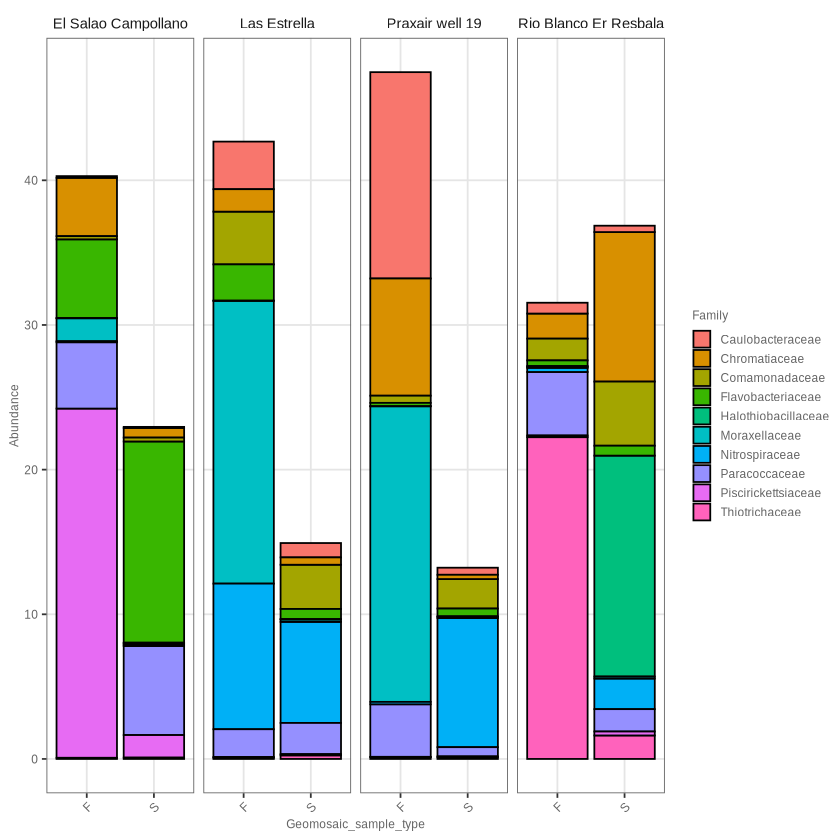

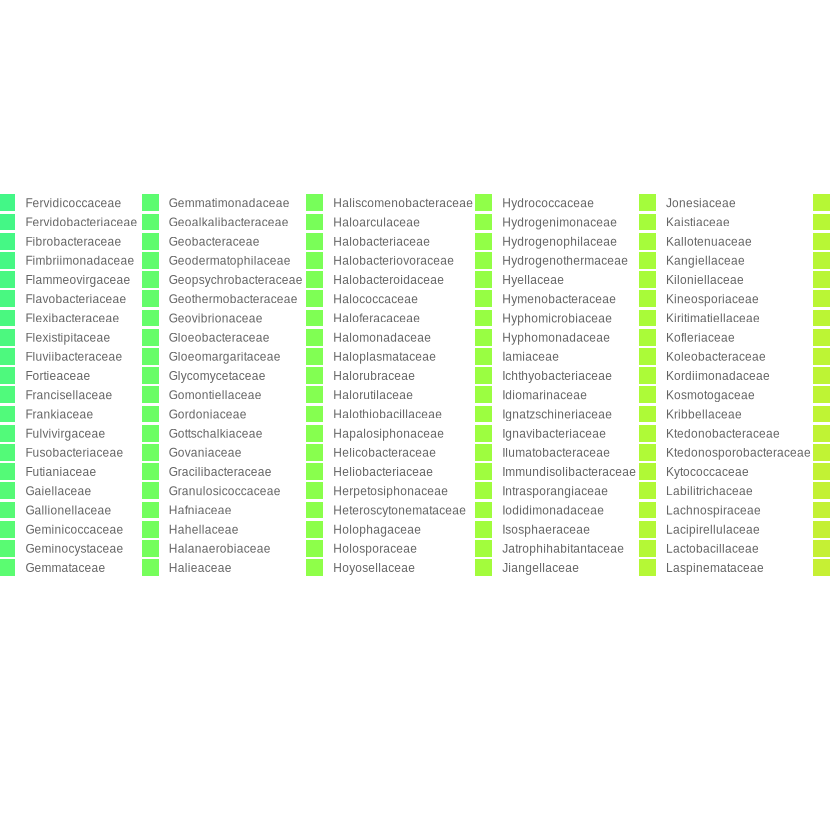

In [ ]:
prok <- subset_taxa(phy, !(Kingdom %in% c("unclassified", "Viruses", "cannot be assigned to a (non-viral) family")))


## Normalizing the asv counts as relative abundances
prok_ndata_ra <- transform_sample_counts(prok, function(x) x/sum(x) * 100 )

N <- 10
# SORT
top10.family <- sort(taxa_sums(prok_ndata_ra), decreasing = TRUE)[1:N]
family.top10.ra <- prune_taxa(names(top10.family), prok_ndata_ra) 

plot_bar(family.top10.ra, x = "Geomosaic_sample_type", fill="Family") + 
  facet_grid(~site_name, scales = "free", space = "free") +
  theme_glab() +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    strip.text.y = element_blank(),  # Rimuove il testo delle righe del facet_grid
    strip.background = element_blank(),  # Rimuove il box di background delle righe del facet_grid
    legend.position = "right",
    panel.grid.major = element_line(color = "grey90")
  )

# converting 
melt <- psmelt(prok_ndata_ra)

plot_stacked <- ggplot(melt, aes(x = Sample, y = Abundance, fill = Family)) +

  geom_bar(stat = "identity", position = "stack", width = 0.7) +
  theme_glab() +
  scale_y_continuous(labels = scales::percent, expand = c(0, 0)) +
  scale_fill_viridis_d(option = "turbo") + 
  labs(
    title = "Relative Abundance of Top 10 Orders",
    x = "Sample",
    y = "Relative Abundance",
    fill = "Order"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(plot_stacked)